# 🧪 시나리오 2: 장애 대응 (Failover & Circuit Breaker)

## 목적
3개 리전에 배포된 Azure OpenAI 중 하나가 과부하(429)되면:
1. **Circuit Breaker가 발동**하여 해당 백엔드를 풀에서 제외
2. 나머지 2개 백엔드가 **자동으로 트래픽을 인수** (Failover)
3. 30초 후 장애 백엔드가 **자동 복귀**

## Circuit Breaker 설정 (현재 Bicep)
```
60초 내 429/5xx 에러 3회 발생 → 해당 백엔드 30초 차단
```

## 흐름
```
Phase 1: 정상 상태 (3개 백엔드 균등)
    ↓
Phase 2: 과부하 → 429 발생 → Circuit Breaker 발동
    ↓
Phase 3: 장애 백엔드 제외, 나머지로 Failover
    ↓
Phase 4: 30초 후 장애 백엔드 복귀
```
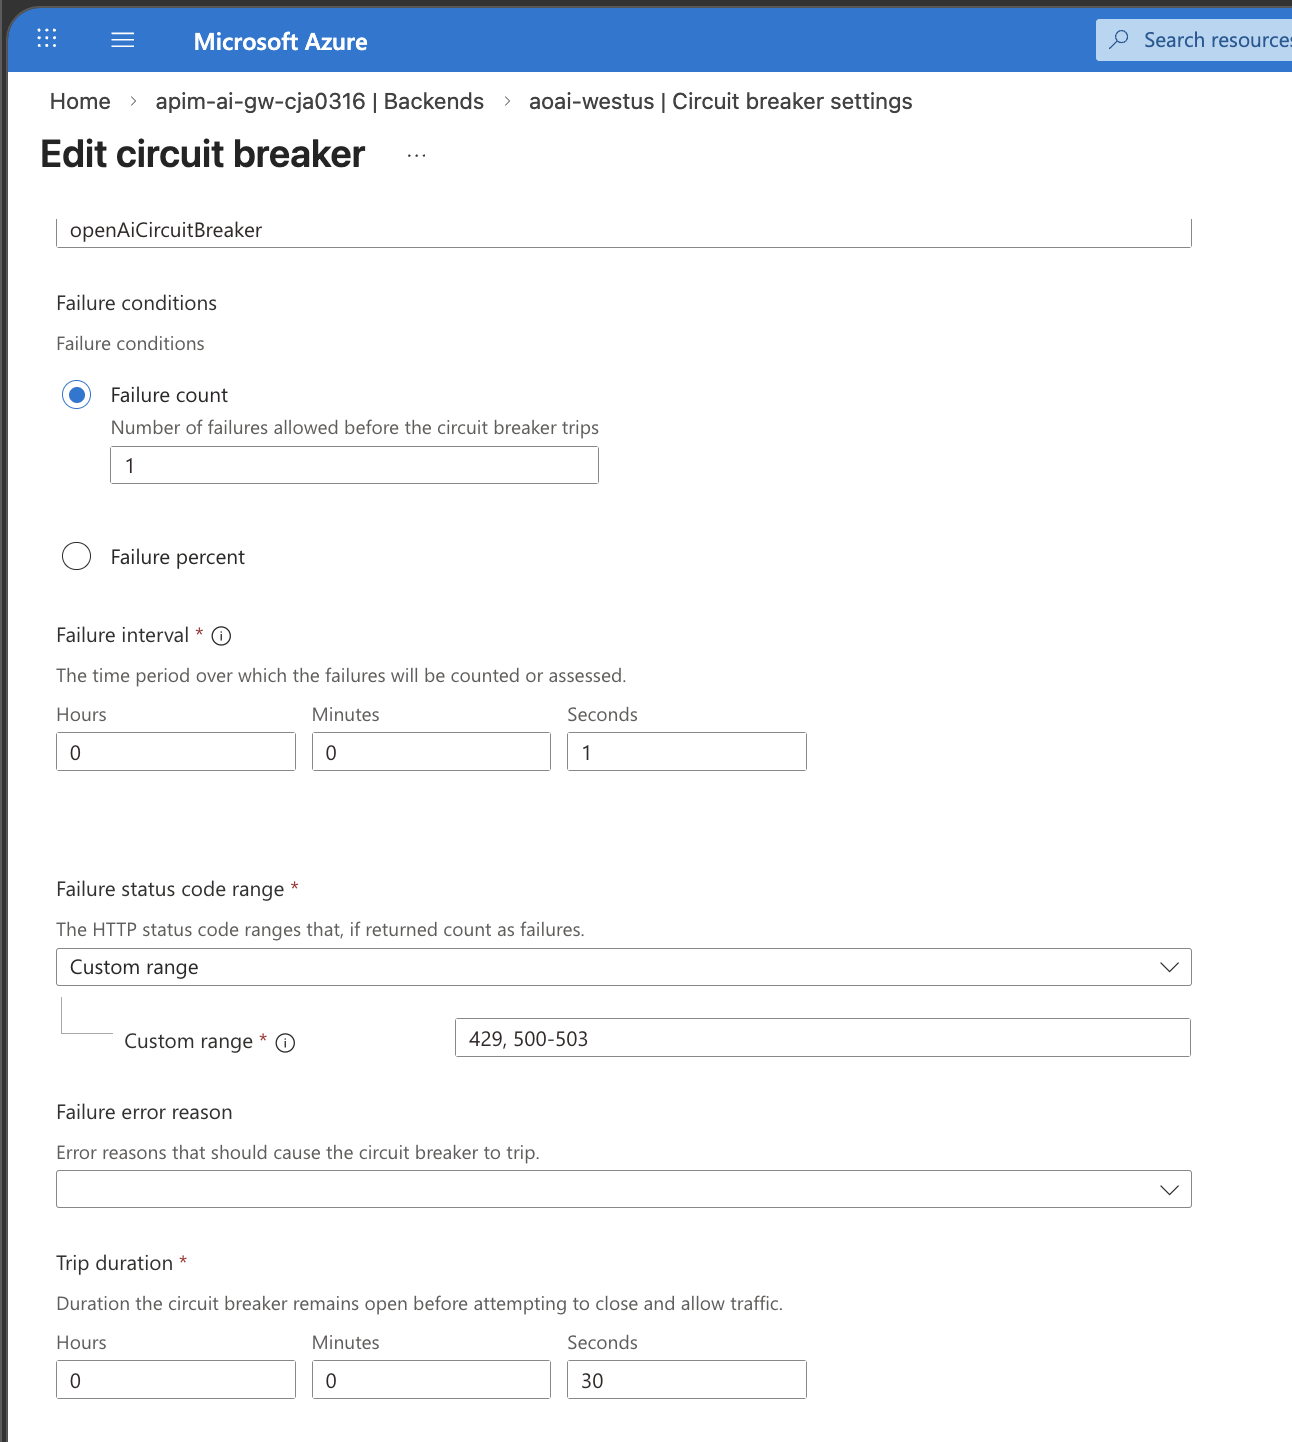

In [ ]:
import os, time, json
from collections import Counter
import requests
from dotenv import load_dotenv

# .env에서 환경 변수 자동 로드
load_dotenv("../../.env")

APIM_URL = os.getenv("APIM_URL")
SUBSCRIPTION_KEY = os.getenv("APIM_SUBSCRIPTION_KEY")
DEPLOYMENT_NAME = os.getenv("DEPLOYMENT_NAME", "gpt-4.1-nano")
API_VERSION = "2025-04-01-preview"

assert APIM_URL, "❌ APIM_URL이 설정되지 않았습니다. .env를 확인하세요."
assert SUBSCRIPTION_KEY, "❌ APIM_SUBSCRIPTION_KEY가 설정되지 않았습니다. .env를 확인하세요."

BASE_URL = f"{APIM_URL}/openai/deployments/{DEPLOYMENT_NAME}/chat/completions"
HEADERS = {
    "Content-Type": "application/json",
    "Ocp-Apim-Subscription-Key": SUBSCRIPTION_KEY
}

def call_api(prompt="Hi", max_tokens=5):
    resp = requests.post(
        BASE_URL,
        params={"api-version": API_VERSION},
        headers=HEADERS,
        json={"messages": [{"role": "user", "content": prompt}], "max_tokens": max_tokens},
        timeout=30
    )
    backend = resp.headers.get("x-backend-url", "unknown")
    return resp.status_code, backend, resp

def short_name(backend):
    return backend.replace(".openai.azure.com", "").replace("https://", "")

print("✅ 환경 설정 완료")
print(f"   APIM URL:    {APIM_URL}")
print(f"   Deployment:  {DEPLOYMENT_NAME}")
print(f"   API Version: {API_VERSION}")
print(f"   Resource Group: {os.getenv('RESOURCE_GROUP')}")

## Phase 1: 정상 상태 확인
9회 호출하여 3개 백엔드가 모두 사용되는지 확인합니다.

In [ ]:
print("▶ Phase 1: 정상 상태 로드밸런싱\n")

phase1_backends = []
for i in range(1, 10):
    code, backend, _ = call_api()
    name = short_name(backend)
    phase1_backends.append(name)
    print(f"  [{i}] {code} → {name}")
    time.sleep(0.3)

phase1_count = Counter(phase1_backends)
print(f"\n📊 정상 상태 분포: {dict(phase1_count)}")
print(f"   사용된 백엔드: {len(phase1_count)}개")

## Phase 2: Bearer Token으로 특정 리전에 직접 과부하

**핵심:** 3개 리전 중 **1개만** TPM을 소진시켜야 합니다.
`az account get-access-token`으로 발급한 **Bearer Token**으로 특정 Azure OpenAI에 직접 호출합니다.

```
az account get-access-token → Bearer Token 발급
    ↓
Phase 1에서 관찰한 백엔드 중 하나에 직접 대량 호출 → TPM 소진
    ↓
해당 리전만 429 상태 (나머지 2개는 정상)
    ↓
Phase 3에서 APIM 호출 → APIM이 해당 리전에서 429 수신 → Circuit Breaker 발동
```

In [ ]:
print("▶ Phase 2: 특정 리전에 직접 과부하 → TPM 소진\n")

# Phase 1에서 관찰된 백엔드 중 하나를 타겟으로 선택
target_backend = phase1_backends[0]
aoai_name = target_backend.replace(".openai.azure.com", "")
print(f"  🎯 타겟 백엔드: {aoai_name}")

# Bearer Token 발급 (Managed Identity 인증)
import subprocess
result = subprocess.run(
    ["az", "account", "get-access-token",
     "--resource", "https://cognitiveservices.azure.com",
     "--query", "accessToken", "-o", "tsv"],
    capture_output=True, text=True
)
bearer_token = result.stdout.strip()
assert bearer_token, "❌ Bearer Token 발급 실패. 'az login' 상태를 확인하세요."
print(f"  🔑 Bearer Token 발급 완료 (길이: {len(bearer_token)}자)\n")

# 타겟 백엔드에 직접 대량 호출
DIRECT_URL = f"https://{target_backend}.openai.azure.com/openai/deployments/{DEPLOYMENT_NAME}/chat/completions"
DIRECT_HEADERS = {"Content-Type": "application/json", "Authorization": f"Bearer {bearer_token}"}

phase2_results = []
count_429 = 0
count_200 = 0

print(f"  {aoai_name}에 직접 대량 호출 시작...\n")

for i in range(1, 30):
    try:
        resp = requests.post(
            DIRECT_URL, params={"api-version": API_VERSION},
            headers=DIRECT_HEADERS,
            json={"messages": [{"role": "user", "content": "Write a very long essay about AI."}], "max_tokens": 4000},
            timeout=60
        )
        code = resp.status_code
    except Exception:
        code = 0

    phase2_results.append({"code": code, "backend": target_backend})

    if code == 429:
        count_429 += 1
        print(f"  [{i:2d}] 🚫 429 → {aoai_name} (직접)")
        if count_429 >= 2:
            print(f"\n  🔴 {aoai_name}의 TPM 소진 완료!")
            print(f"     → Phase 3에서 APIM 호출 시 Circuit Breaker 발동을 확인합니다.")
            break
    elif code == 200:
        count_200 += 1
        print(f"  [{i:2d}] ✅ 200 → {aoai_name} (직접)")
    else:
        print(f"  [{i:2d}] ⚠️ {code} → {aoai_name} (직접)")

    time.sleep(0.05)

print(f"\n📊 직접 호출 결과: 200={count_200}, 429={count_429}")
print(f"   타겟 리전({aoai_name})만 과부하 → 나머지 2개는 정상")

## Phase 3: APIM 호출 → Failover 확인

이제 **APIM 백엔드 풀**을 통해 호출합니다.
- APIM이 Round Robin으로 과부하된 리전에 요청 → **Azure OpenAI가 429 반환** → **Circuit Breaker 발동**
- 이후 요청은 **나머지 2개 리전으로만** 라우팅됩니다

**확인 포인트:**
- 처음 몇 회 호출에서 429가 발생할 수 있음 (Circuit Breaker 발동 전)
- 이후부터는 과부하 리전이 제외되고 **2개 리전에서만 200** 응답

In [ ]:
print("▶ Phase 3: Failover 확인 (장애 백엔드 제외 여부)\n")

phase3_backends = []
for i in range(1, 15):
    code, backend, _ = call_api()
    name = short_name(backend)
    phase3_backends.append(name)
    print(f"  [{i}] {code} → {name}")
    time.sleep(0.5)

phase3_count = Counter(phase3_backends)
print(f"\n📊 Failover 중 백엔드 분포: {dict(phase3_count)}")
print(f"   사용된 백엔드: {len(phase3_count)}개")

if len(phase3_count) < len(phase1_count):
    excluded = set(phase1_count.keys()) - set(phase3_count.keys())
    print(f"\n✅ Circuit Breaker 동작 확인!")
    print(f"   제외된 백엔드: {excluded}")
    print(f"   Phase 1: {len(phase1_count)}개 → Phase 3: {len(phase3_count)}개")
else:
    print(f"\nℹ️ 모든 백엔드가 여전히 사용 중 (Circuit Breaker 미발동 또는 이미 복구)")

## Phase 4: 복구 대기 후 백엔드 복귀 확인

Circuit Breaker의 `tripDuration`은 30초입니다.
30초를 기다린 후 장애 백엔드가 다시 풀에 복귀하는지 확인합니다.

In [ ]:
print("⏳ Circuit Breaker tripDuration(30초) 대기 중...")
for remaining in range(30, 0, -5):
    print(f"   {remaining}초 남음...")
    time.sleep(5)
print("   대기 완료!\n")

print("▶ Phase 4: 복구 후 백엔드 상태 확인\n")

phase4_backends = []
for i in range(1, 10):
    code, backend, _ = call_api()
    name = short_name(backend)
    phase4_backends.append(name)
    print(f"  [{i}] {code} → {name}")
    time.sleep(0.5)

phase4_count = Counter(phase4_backends)
print(f"\n📊 복구 후 백엔드 분포: {dict(phase4_count)}")
print(f"   사용된 백엔드: {len(phase4_count)}개")

if len(phase4_count) >= 3:
    print("\n✅ 모든 백엔드 복귀 완료! Auto-Recovery 확인")
elif len(phase4_count) > len(phase3_count):
    print(f"\n✅ 일부 복귀: {len(phase3_count)}개 → {len(phase4_count)}개")

## 전체 요약

In [ ]:
print("═" * 55)
print(" Failover & Circuit Breaker 테스트 요약")
print("═" * 55)
print(f"")
print(f"  Phase 1 (정상):  {len(phase1_count)}개 백엔드 → {dict(phase1_count)}")
print(f"  Phase 2 (과부하): 429 발생 {count_429}회")
print(f"  Phase 3 (장애):  {len(phase3_count)}개 백엔드 → {dict(phase3_count)}")
print(f"  Phase 4 (복구):  {len(phase4_count)}개 백엔드 → {dict(phase4_count)}")
print(f"")
print("─" * 55)

# 판정
checks = {
    "로드밸런싱 (3개 백엔드 분산)": len(phase1_count) >= 3,
    "Circuit Breaker (장애 백엔드 제외)": len(phase3_count) < len(phase1_count),
    "Auto Recovery (백엔드 복귀)": len(phase4_count) > len(phase3_count),
    "서비스 연속성 (장애 중 200 응답)": any(r["code"] == 200 for r in phase2_results[-10:])
}

for check, passed in checks.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon} {check}")

## Phase 5: 백엔드 장애 시뮬레이션 (모델 삭제)

실제 프로덕션에서 발생할 수 있는 시나리오입니다:
- 특정 리전의 **모델이 삭제**되거나 배포가 실패한 경우
- 백엔드가 **404 (모델 없음)**을 반환
- Circuit Breaker가 발동하여 **서비스 중단 없이** 나머지 리전으로 자동 전환

**주의:** 기본 Circuit Breaker 설정(429, 500-503)에는 **404가 포함되어 있지 않습니다.**
모델 삭제 시 404를 감지하려면 Circuit Breaker에 404를 추가해야 합니다.

```
Phase 5-1: 모델 삭제 + Circuit Breaker에 404 추가
    ↓
Phase 5-2: APIM 호출 → 404 → Circuit Breaker 발동 → 나머지 2개로 정상 서비스
    ↓
Phase 5-3: 모델 재배포 → 자동 복구
```

> ⚠️ 이 테스트는 **실제로 모델을 삭제**합니다. Phase 5-3에서 재배포합니다.

### 404는 아래 오류코드 Circuit breaker는 아래 코드를 실행하면 추가됩니다.
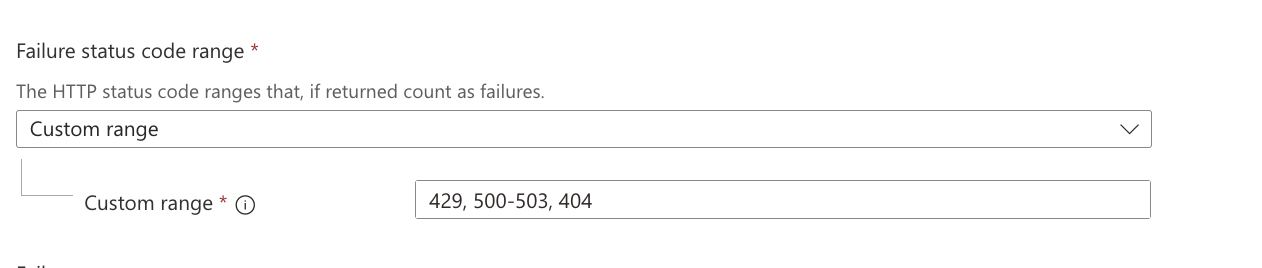

In [ ]:
print("▶ Phase 5-1: 특정 리전의 모델 삭제\n")

# 타겟 백엔드 선택 (Phase 1에서 관찰된 첫 번째 백엔드)
target = phase1_backends[0]
aoai_name = target.replace(".openai.azure.com", "")
RESOURCE_GROUP = os.getenv("RESOURCE_GROUP")

print(f"  🎯 타겟: {aoai_name}")
print(f"  ⚠️  {DEPLOYMENT_NAME} 모델을 삭제합니다...\n")

import subprocess
result = subprocess.run(
    ["az", "cognitiveservices", "account", "deployment", "delete",
     "--name", aoai_name,
     "--resource-group", RESOURCE_GROUP,
     "--deployment-name", DEPLOYMENT_NAME],
    capture_output=True, text=True
)

if result.returncode == 0:
    print(f"  ✅ {aoai_name}의 {DEPLOYMENT_NAME} 모델 삭제 완료")
    print(f"     → 이제 APIM이 이 리전에 요청하면 404가 반환됩니다.")
else:
    print(f"  ❌ 삭제 실패: {result.stderr[:300]}")

# Circuit Breaker에 404 추가 (기존: 429, 500-503 → 404 추가)
print(f"\n  🔧 Circuit Breaker에 404 에러 코드 추가 중...")
print(f"     (모델 삭제 시 404가 반환되므로, 이걸 감지해야 자동 제외됩니다)\n")

APIM_NAME = os.getenv("APIM_NAME")
apim_id_result = subprocess.run(
    ["az", "apim", "show", "--name", APIM_NAME, "--resource-group", RESOURCE_GROUP, "--query", "id", "-o", "tsv"],
    capture_output=True, text=True
)
apim_id = apim_id_result.stdout.strip()

# 3개 백엔드 모두에 404 추가
for backend_name in ["aoai-eastus", "aoai-swedencentral", "aoai-westus"]:
    # 현재 백엔드 설정 가져오기
    get_result = subprocess.run(
        ["az", "rest", "--method", "GET",
         "--url", f"https://management.azure.com{apim_id}/backends/{backend_name}?api-version=2023-09-01-preview"],
        capture_output=True, text=True
    )
    if get_result.returncode == 0:
        backend_config = json.loads(get_result.stdout)
        # Circuit Breaker에 404 추가
        rules = backend_config.get("properties", {}).get("circuitBreaker", {}).get("rules", [])
        if rules:
            status_ranges = rules[0].get("failureCondition", {}).get("statusCodeRanges", [])
            # 404가 없으면 추가
            has_404 = any(r.get("min") == 404 and r.get("max") == 404 for r in status_ranges)
            if not has_404:
                status_ranges.append({"min": 404, "max": 404})
                rules[0]["failureCondition"]["statusCodeRanges"] = status_ranges
                backend_config["properties"]["circuitBreaker"]["rules"] = rules
                
                # 업데이트
                put_result = subprocess.run(
                    ["az", "rest", "--method", "PUT",
                     "--url", f"https://management.azure.com{apim_id}/backends/{backend_name}?api-version=2023-09-01-preview",
                     "--body", json.dumps(backend_config)],
                    capture_output=True, text=True
                )
                if put_result.returncode == 0:
                    print(f"  ✅ {backend_name}: Circuit Breaker에 404 추가 완료")
                else:
                    print(f"  ❌ {backend_name}: 업데이트 실패 - {put_result.stderr[:100]}")
            else:
                print(f"  ℹ️ {backend_name}: 404 이미 포함됨")

print(f"\n  → 이제 404 발생 시에도 Circuit Breaker가 발동됩니다.")

In [ ]:
print("▶ Phase 5-2: APIM 호출 → 모델 삭제된 리전 자동 제외 확인\n")
print(f"  💡 {aoai_name}의 모델이 삭제되어 404/500을 반환할 것입니다.\n")

phase5_backends = []
phase5_errors = 0

for i in range(1, 15):
    code, backend, _ = call_api()
    name = short_name(backend)
    phase5_backends.append(name)
    
    if code == 200:
        print(f"  [{i}] ✅ 200 → {name}")
    elif code == 429:
        print(f"  [{i}] 🚫 429 → {name}")
    elif code == 502:
        phase5_errors += 1
        print(f"  [{i}] ⚠️ 502 → {name} (Circuit Breaker 발동 전)")
    else:
        phase5_errors += 1
        print(f"  [{i}] ⚠️ {code} → {name}")
    time.sleep(0.5)

phase5_count = Counter(phase5_backends)
phase5_success = sum(1 for b in phase5_backends if b != "unknown")

print(f"\n📊 백엔드 분포: {dict(phase5_count)}")
print(f"   사용된 백엔드: {len([k for k in phase5_count if k != 'unknown'])}개")

if target not in phase5_count or phase5_count.get(target, 0) == 0:
    print(f"\n✅ 모델 삭제된 백엔드({aoai_name})가 자동 제외되었습니다!")
    print(f"   → 서비스 중단 없이 나머지 리전으로 정상 운영 확인")
elif phase5_errors <= 2:
    print(f"\n✅ 초반 1-2회 오류 후 Circuit Breaker 발동 → 서비스 정상화")
else:
    print(f"\nℹ️  Circuit Breaker 동작 확인 필요")

In [ ]:
print("▶ Phase 5-3: 모델 재배포 → 자동 복구 확인\n")

# 삭제한 모델 재배포
print(f"  🔄 {aoai_name}에 {DEPLOYMENT_NAME} 모델 재배포 중...\n")

result = subprocess.run(
    ["az", "cognitiveservices", "account", "deployment", "create",
     "--name", aoai_name,
     "--resource-group", RESOURCE_GROUP,
     "--deployment-name", DEPLOYMENT_NAME,
     "--model-name", "gpt-4.1-nano",
     "--model-version", "2025-04-14",
     "--model-format", "OpenAI",
     "--sku-capacity", "5",
     "--sku-name", "GlobalStandard"],
    capture_output=True, text=True
)

if result.returncode == 0:
    print(f"  ✅ {aoai_name}에 {DEPLOYMENT_NAME} 재배포 완료\n")
else:
    print(f"  ❌ 재배포 실패: {result.stderr[:200]}\n")

# tripDuration(30초) 대기 후 복구 확인
print("  ⏳ Circuit Breaker tripDuration(30초) 대기 중...")
for remaining in range(30, 0, -10):
    print(f"     {remaining}초 남음...")
    time.sleep(10)
print("     대기 완료!\n")

# 복구 확인
phase5_recovery = []
for i in range(1, 10):
    code, backend, _ = call_api()
    name = short_name(backend)
    phase5_recovery.append(name)
    print(f"  [{i}] {code} → {name}")
    time.sleep(0.5)

phase5r_count = Counter(phase5_recovery)
print(f"\n📊 복구 후 백엔드 분포: {dict(phase5r_count)}")

if len(phase5r_count) >= 3:
    print(f"\n✅ 모든 백엔드 복구 완료! (3개 리전 정상)")
    print(f"   → 모델 재배포만으로 서비스가 자동 복원됩니다.")
else:
    print(f"\n⚠️  아직 일부 백엔드 복구 중 ({len(phase5r_count)}개)")